## Create the equal-weight portfolio

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
daily_returns = pd.read_csv(
    "daily_returns.csv",
    index_col=0,
    parse_dates=True
)

annualized_covariance = pd.read_csv(
    "annualized_covariance_matrix.csv",
    index_col=0
)

risk_return = pd.read_csv(
    "risk_return_summary.csv",
    index_col=0
)

In [3]:
n_assets = len(daily_returns.columns)

weights = np.ones(n_assets) / n_assets

In [4]:
weights

array([0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05,
       0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05])

In [5]:
weights.sum()

np.float64(1.0000000000000002)

#### Portfolio Return

In [6]:
expected_returns = risk_return["Annualized Return (%)"].values / 100

portfolio_return = np.dot(weights, expected_returns)

print("Expected annual portfolio return:",
      portfolio_return * 100, "%")

Expected annual portfolio return: 19.637606376917834 %


#### Portfolio Variance

In [7]:
cov_matrix = annualized_covariance.values

portfolio_variance = (
    weights.T @ cov_matrix @ weights
)

print("Portfolio variance:", portfolio_variance)

Portfolio variance: 0.026239425589961923


#### Portfolio Volatility

In [8]:
portfolio_volatility = np.sqrt(portfolio_variance)

print(
    "Portfolio volatility:",
    portfolio_volatility * 100,
    "%"
)

Portfolio volatility: 16.198588083521948 %


In [9]:
average_stock_volatility = (
    risk_return["Annualized Volatility (%)"].mean()
)

print(
    "Average individual stock volatility:",
    average_stock_volatility,
    "%"
)

print(
    "Portfolio volatility:",
    portfolio_volatility * 100,
    "%"
)

Average individual stock volatility: 27.663312213450173 %
Portfolio volatility: 16.198588083521948 %


In [12]:
# Individual stock annualized return and volatility
stock_returns = risk_return["Annualized Return (%)"]
stock_volatility = risk_return["Annualized Volatility (%)"]

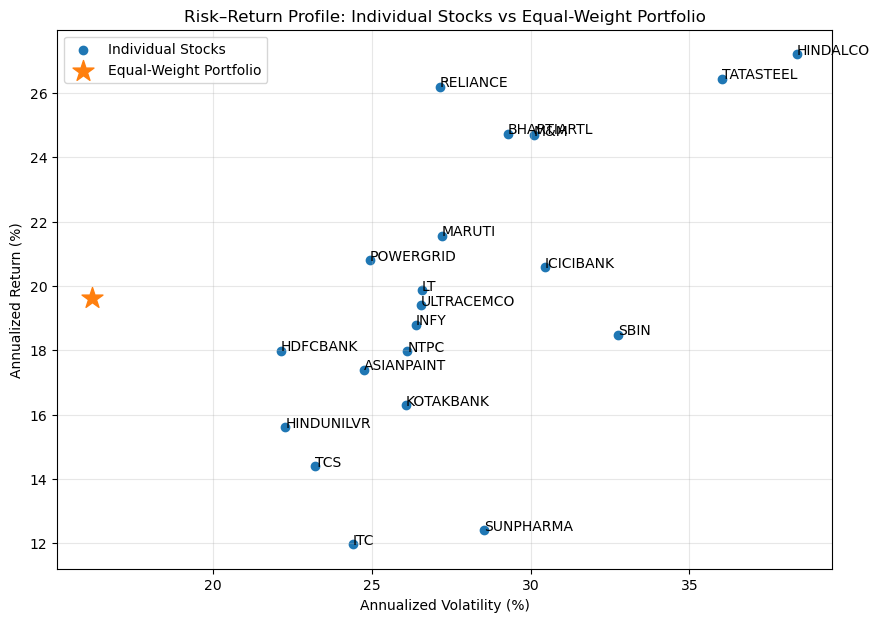

In [13]:
plt.figure(figsize=(10, 7))

plt.scatter(
    stock_volatility,
    stock_returns,
    label="Individual Stocks"
)

plt.scatter(
    portfolio_volatility * 100,
    portfolio_return * 100,
    marker="*",
    s=250,
    label="Equal-Weight Portfolio"
)

for stock in stock_returns.index:
    plt.annotate(
        stock.replace(".NS", ""),
        (
            stock_volatility.loc[stock],
            stock_returns.loc[stock]
        )
    )

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Annualized Return (%)")
plt.title("Risk–Return Profile: Individual Stocks vs Equal-Weight Portfolio")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [14]:
print(stock_returns.head())
print(stock_volatility.head())
print(portfolio_return)
print(portfolio_volatility)

ASIANPAINT.NS    17.393115
BHARTIARTL.NS    24.730435
HDFCBANK.NS      17.988186
HINDALCO.NS      27.206099
HINDUNILVR.NS    15.601564
Name: Annualized Return (%), dtype: float64
ASIANPAINT.NS    24.764551
BHARTIARTL.NS    29.283158
HDFCBANK.NS      22.143553
HINDALCO.NS      38.382629
HINDUNILVR.NS    22.273578
Name: Annualized Volatility (%), dtype: float64
0.19637606376917832
0.16198588083521948


In [15]:
risk_free_rate = 0.06

In [16]:
sharpe_ratio = (
    portfolio_return - risk_free_rate
) / portfolio_volatility

print("Sharpe Ratio:", sharpe_ratio)

Sharpe Ratio: 0.8419009302909999
